In [2]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Exploratory Data Analysis**

In [ ]:
# Load the Excel file
path = '/content/drive/MyDrive/Vivarttana Technologies Internship /DA projects /DA_Credit card fraud_project/Credit_Card_Fraud.csv'

# Load the data (adjust the sheet name if needed)
df = pd.read_csv(path, index_col=0)
print(df)

                                        merchant        category     amt  \
trans_date_trans_time                                                      
2019-01-01 00:00:44    Heller, Gutmann and Zieme     grocery_pos  107.23   
2019-01-01 00:00:51               Lind-Buckridge   entertainment  220.11   
2019-01-01 00:07:27                    Kiehn Inc     grocery_pos   96.29   
2019-01-01 00:09:03                  Beier-Hyatt    shopping_pos    7.77   
2019-01-01 00:21:32                   Bruen-Yost        misc_pos    6.85   
...                                          ...             ...     ...   
2020-12-31 23:57:56               Schmidt-Larkin            home   12.68   
2020-12-31 23:58:04    Pouros, Walker and Spence       kids_pets   13.02   
2020-12-31 23:59:07              Reilly and Sons  health_fitness   43.77   
2020-12-31 23:59:15                    Rau-Robel       kids_pets   86.88   
2020-12-31 23:59:24              Breitenberg LLC          travel    7.99   

           



---


### **1. Perform below mentioned information gathering on the credit card fraud dataset**
**a**. Check for any NULL values

**b**. Derive the new feature Age into the data frame using dob feature

**c**. Check the shape of the data frame





In [ ]:
# a. Check for any NULL values
print("Checking for NULL values:")
df.isnull().sum()

Checking for NULL values:


,0
merchant,0
category,0
amt,0
city,0
state,0
lat,0
long,0
city_pop,0
job,0
dob,0


In [ ]:
df['dob'] = pd.to_datetime(df['dob'])
print(df['dob'])


from datetime import datetime
today = datetime.today() #Gets the current date and time

df['Age'] = df['dob'].apply(lambda dob: today.year - dob.year - ((today.month, today.day) < (dob.month, dob.day)))
print(df['Age'])


#1. apply() runs the lambda function for each value in the DOB column.
#2. today.year - dob.year -gives the difference in years between the current year and the year of birth.
#3. ((today.month, today.day) < (dob.month, dob.day))  -
                          #This checks whether the birthday has occurred yet this year:
                          #It returns True (which acts as 1) if today is before the birthday.
                          #It returns False (which acts as 0) if today is on or after the birthday.


trans_date_trans_time
2019-01-01 00:00:44   1978-06-21
2019-01-01 00:00:51   1962-01-19
2019-01-01 00:07:27   1945-12-21
2019-01-01 00:09:03   1967-08-30
2019-01-01 00:21:32   1967-08-02
                         ...    
2020-12-31 23:57:56   1939-11-09
2020-12-31 23:58:04   1958-09-20
2020-12-31 23:59:07   1966-02-13
2020-12-31 23:59:15   1981-11-29
2020-12-31 23:59:24   1965-12-15
Name: dob, Length: 339607, dtype: datetime64[ns]
trans_date_trans_time
2019-01-01 00:00:44    47
2019-01-01 00:00:51    63
2019-01-01 00:07:27    79
2019-01-01 00:09:03    57
2019-01-01 00:21:32    58
                       ..
2020-12-31 23:57:56    85
2020-12-31 23:58:04    66
2020-12-31 23:59:07    59
2020-12-31 23:59:15    43
2020-12-31 23:59:24    59
Name: Age, Length: 339607, dtype: int64


In [ ]:
print("\nShape of the data frame (rows, columns):")
df.shape


Shape of the data frame (rows, columns):


(339607, 15)



---
### 2. List all the merchants who are fraud along with their DoB and fraud count


In [ ]:
fraud = df[df['is_fraud'] == 1]

fraud_count = fraud.groupby('merchant')['dob'].size().reset_index(name='Fraud_Count')
#fraud_count = fraud.groupby(['merchant', 'dob']).size().reset_index(name='Fraud_Count')
print(fraud_count)

#.size() counts how many times each unique combination appears.

                       merchant  Fraud_Count
0                 Abbott-Rogahn            2
1                 Abbott-Steube            1
2            Abernathy and Sons            2
3                   Abshire PLC            2
4    Adams, Kovacek and Kuhlman            1
..                          ...          ...
504   Zboncak, Rowe and Murazik            5
505                Zemlak Group            6
506              Ziemann-Waters            1
507      Zieme, Bode and Dooley            2
508                  Zulauf LLC            1

[509 rows x 2 columns]




---

### 3. If the merchant ‘Welch Inc’ is fraud then display all the features and transactions of this merchant

In [ ]:
welch_fraud = df[(df['merchant'] == 'Welch Inc') & (df['is_fraud'] == 1)]

print(welch_fraud)

                        merchant  category     amt         city state  \
trans_date_trans_time                                                   
2019-05-16 23:54:36    Welch Inc  misc_net  803.64     Campbell    NE   
2019-05-22 02:26:28    Welch Inc  misc_net  828.47  Smith River    CA   
2019-06-14 03:26:43    Welch Inc  misc_net  819.53     San Jose    CA   
2019-06-17 13:45:25    Welch Inc  misc_net  650.50     Syracuse    MO   
2020-02-10 23:17:42    Welch Inc  misc_net  709.61        Sixes    OR   
2020-02-10 23:58:42    Welch Inc  misc_net  764.72        Sixes    OR   
2020-05-01 22:14:21    Welch Inc  misc_net  806.06    Louisiana    MO   
2020-09-17 22:41:50    Welch Inc  misc_net  898.89     Palmdale    CA   

                           lat      long  city_pop                       job  \
trans_date_trans_time                                                          
2019-05-16 23:54:36    40.2967  -98.7370       493        Surveyor, minerals   
2019-05-22 02:26:28    41.940



---
### 4. If the merchant ‘Romaguera, Cruickshank and Greenholt’ is fraud then display all the features of this merchant


In [ ]:
merchant_fraud = df[(df['merchant'] == 'Romaguera, Cruickshank and Greenholt') & (df['is_fraud'] == 1)]

# Display the result
print(merchant_fraud)

                                                   merchant      category  \
trans_date_trans_time                                                       
2019-01-28 23:14:49    Romaguera, Cruickshank and Greenholt  shopping_net   
2019-03-11 23:03:05    Romaguera, Cruickshank and Greenholt  shopping_net   
2019-05-29 20:54:14    Romaguera, Cruickshank and Greenholt  shopping_net   
2019-08-19 00:45:59    Romaguera, Cruickshank and Greenholt  shopping_net   
2019-09-07 23:52:10    Romaguera, Cruickshank and Greenholt  shopping_net   
2019-12-31 22:17:45    Romaguera, Cruickshank and Greenholt  shopping_net   
2020-02-23 23:40:47    Romaguera, Cruickshank and Greenholt  shopping_net   
2020-03-15 23:59:54    Romaguera, Cruickshank and Greenholt  shopping_net   
2020-04-13 16:49:02    Romaguera, Cruickshank and Greenholt  shopping_net   
2020-07-31 23:08:01    Romaguera, Cruickshank and Greenholt  shopping_net   
2020-07-31 23:49:08    Romaguera, Cruickshank and Greenholt  shopping_net   



---

### 5. List the fraud count with respect to product category also show the visualization using an appropriate graph

          category  Count
2    gas_transport  35089
4      grocery_pos  32732
6             home  32516
12    shopping_pos  30329
7        kids_pets  29704
11    shopping_net  26379
10   personal_care  24406
0    entertainment  24222
1      food_dining  23038
5   health_fitness  22593
9         misc_pos  20024
8         misc_net  16898
3      grocery_net  11355
13          travel  10322

Top 3 Fraud Categories:

        category  Count
2  gas_transport  35089
4    grocery_pos  32732
6           home  32516


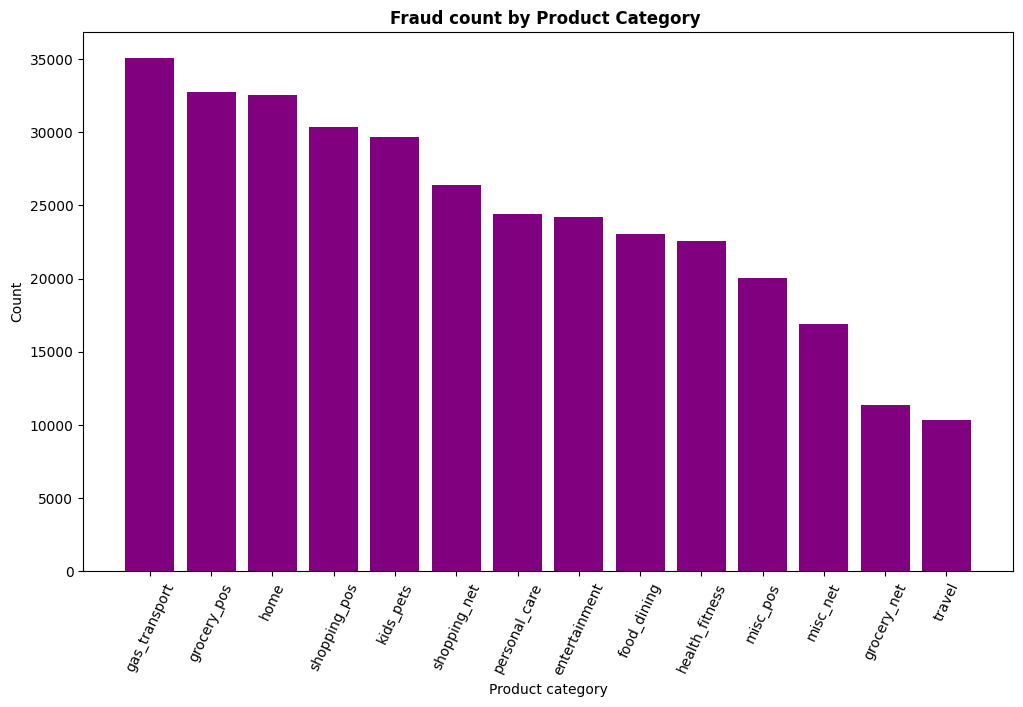

In [ ]:
product_category_count = df.groupby('category').size().reset_index(name='Count')
product_category_count = product_category_count.sort_values(by="Count", ascending=False)
print(product_category_count)

print("\nTop 3 Fraud Categories:\n")
print(product_category_count.head(3))

plt.figure(figsize=(12,7))
plt.bar(product_category_count['category'],product_category_count['Count'], color='purple')
plt.title('Fraud count by Product Category ', fontweight='bold')
plt.xlabel('Product category')
plt.ylabel('Count')
plt.xticks(rotation=65)
plt.show()



---

### 6. List the total fraud amount for every product category and show the visualization using appropriate graph

          category  Total Amount
0    entertainment       1526832
1      food_dining       1155918
2    gas_transport       2184036
3      grocery_net        613442
4      grocery_pos       4063087
5   health_fitness       1212706
6             home       1839601
7        kids_pets       1644635
8         misc_net       1347411
9         misc_pos       1231075
10   personal_care       1178013
11    shopping_net       2274684
12    shopping_pos       2409747
13          travel       1120177


/tmp/ipython-input-2077837209.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_category_amount, x='category', y='Total Amount', palette='Set2')


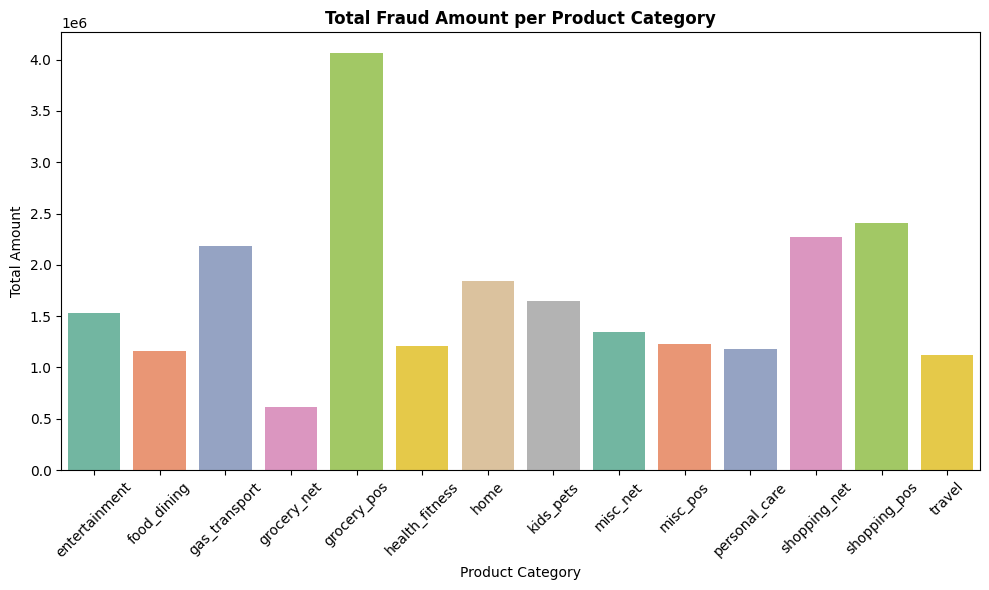

In [ ]:
df['amt'] = df['amt'].astype(int)
product_category_amount = df.groupby('category')['amt'].sum().reset_index(name='Total Amount')
print(product_category_amount)


plt.figure(figsize=(10, 6))
sns.barplot(data=product_category_amount, x='category', y='Total Amount', palette='Set2')

# Add titles and labels
plt.title("Total Fraud Amount per Product Category", fontweight='bold')
plt.xlabel("Product Category")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()



---

### 7. List the total fraud amount for every state and show the visualization using appropriate graph

   state  Total Amount
0     AK        209268
1     AZ       1148661
2     CA       5867263
3     CO       1527470
4     HI        214041
5     ID        598892
6     MO       3710607
7     NE       2253034
8     NM       1423319
9     OR       1826586
10    UT        967626
11    WA       1969041
12    WY       2085556


/tmp/ipython-input-2146285317.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_amount, x='state', y='Total Amount', palette='Set3')


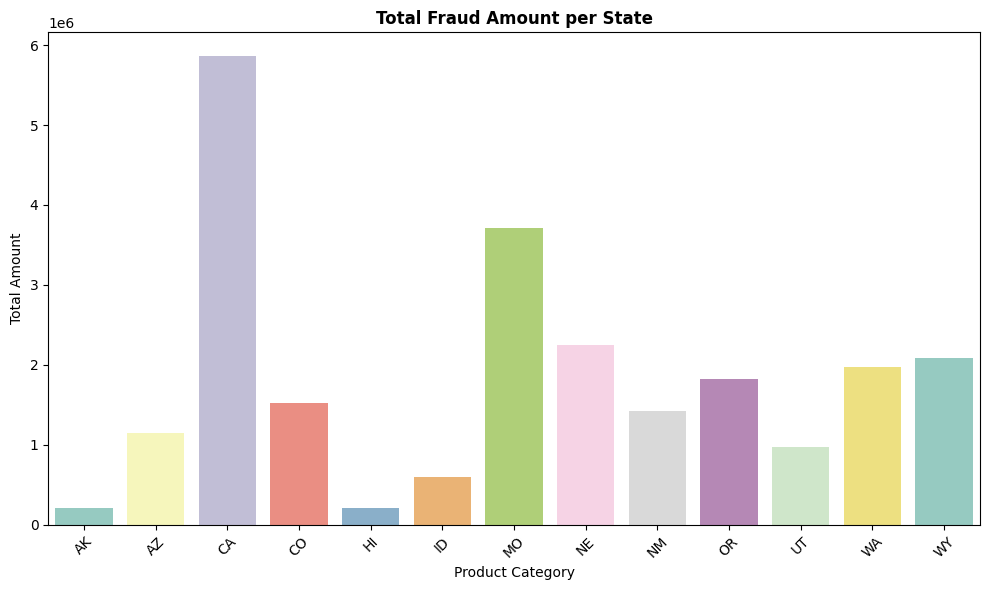

In [ ]:
df['amt'] = df['amt'].astype(int)
state_amount = df.groupby('state')['amt'].sum().reset_index(name='Total Amount')
print(state_amount)

plt.figure(figsize=(10, 6))
sns.barplot(data=state_amount, x='state', y='Total Amount', palette='Set3')

# Add titles and labels
plt.title("Total Fraud Amount per State", fontweight='bold')
plt.xlabel("Product Category")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()



---

### 8. Calculate and list total transactions per state and show the visualization using appropriate graph

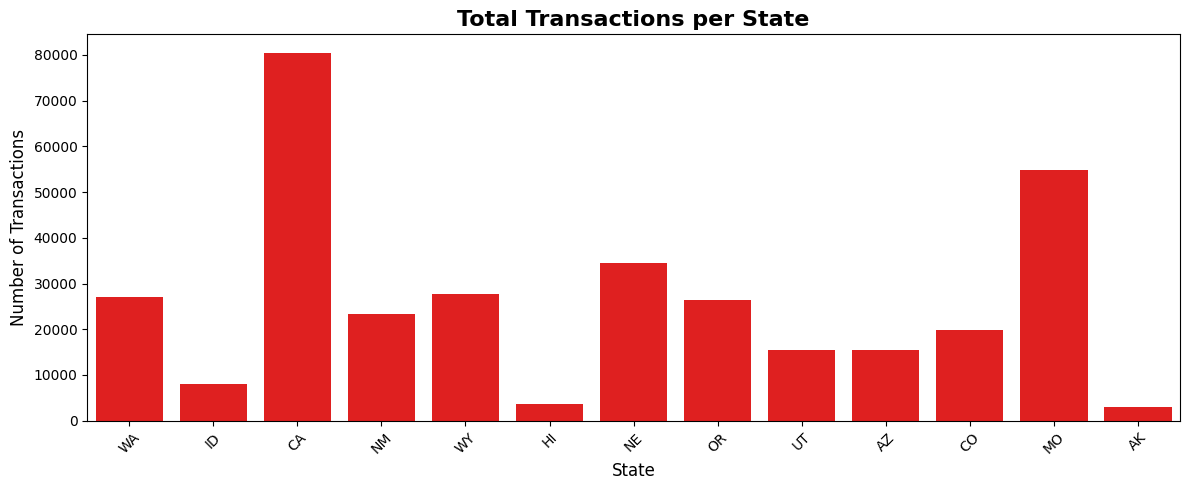

In [ ]:
plt.figure(figsize=(12, 5))
# Create the countplot directly from the DataFrame
sns.countplot(data=df, x='state', color='red')

# Set title and labels
plt.title('Total Transactions per State', fontsize=16, fontweight='bold')
plt.xlabel('State', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()



---

### 9. Calculate and list total number of fraud transactions per state and show the visualization using appropriate graph

   state  Fraud Transactions
0     AK                  50
1     AZ                  64
2     CA                 402
3     CO                 115
4     HI                  16
5     ID                  33
6     MO                 262
7     NE                 216
8     NM                 121
9     OR                 197
10    UT                  61
11    WA                 126
12    WY                 119


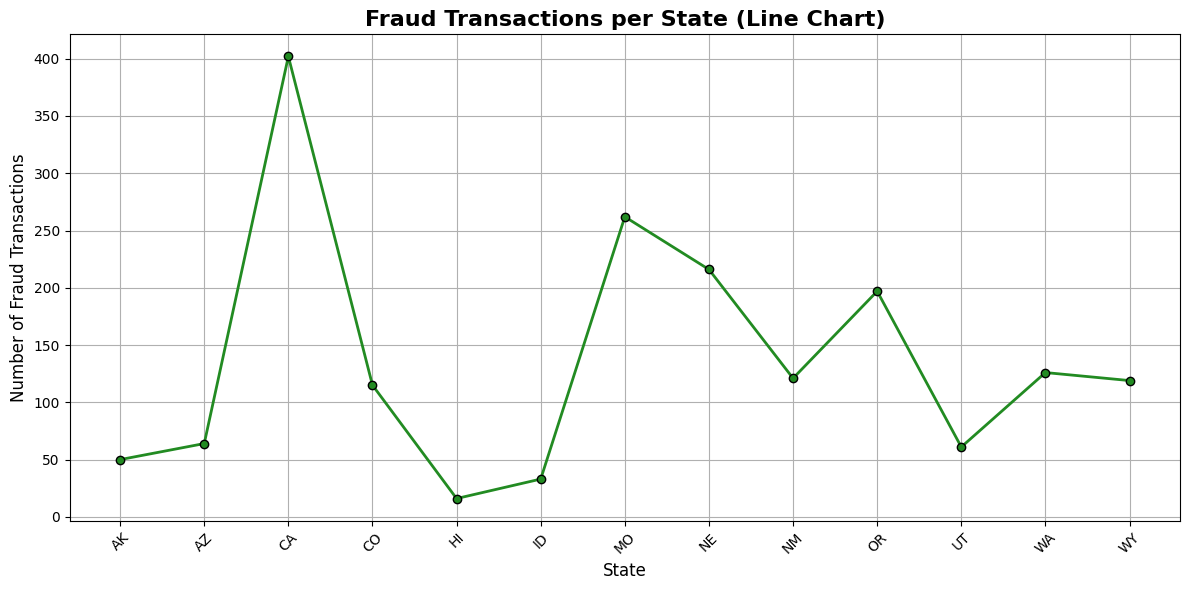

In [ ]:
fraud = df[df['is_fraud'] == 1]

fraud_per_state = fraud.groupby('state').size().reset_index(name='Fraud Transactions')
print(fraud_per_state)

plt.figure(figsize=(12, 6))
plt.plot(fraud_per_state['state'], fraud_per_state['Fraud Transactions'], marker='o', color='forestgreen', linestyle='-', linewidth=2, markeredgecolor='black')

# Titles and labels
plt.title('Fraud Transactions per State (Line Chart)', fontsize=16, fontweight='bold')
plt.xlabel('State', fontsize=12)
plt.ylabel('Number of Fraud Transactions', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)  # Optional: adds grid lines for better readability
plt.tight_layout()
plt.show()



---

### 10.List state-wise total number of transactions and total number of fraud transactions
(hint: use merge function from pandas library to merge the data frame obtained fromthe above 2 steps)

In [ ]:
total_transactions = df.groupby('state').size().reset_index(name='Total Transactions')

fraud_transactions = df[df['is_fraud'] == 1].groupby('state').size().reset_index(name='Fraud Transactions')

#Merge both results on 'state'
statewise_summary = pd.merge(total_transactions, fraud_transactions, on='state', how='left')
print(statewise_summary)


# Merges the two DataFrames (total_transactions and fraud_transactions) using 'state' as the key.
#how='left' ensures that all states from total_transactions will be kept, even if a state has no fraud transactions (to avoid missing data).



   state  Total Transactions  Fraud Transactions
0     AK                2963                  50
1     AZ               15362                  64
2     CA               80495                 402
3     CO               19766                 115
4     HI                3649                  16
5     ID                8035                  33
6     MO               54904                 262
7     NE               34425                 216
8     NM               23427                 121
9     OR               26408                 197
10    UT               15357                  61
11    WA               27040                 126
12    WY               27776                 119




---
### 11. List the Fraud Distribution state-wise i.e check how many fraudulent vs non-fraudulent transactions and show the visualization accordingly


   state    Fraud Status  Transaction Count
0     AK  Non-Fraudulent               2913
1     AK      Fraudulent                 50
2     AZ  Non-Fraudulent              15298
3     AZ      Fraudulent                 64
4     CA  Non-Fraudulent              80093
5     CA      Fraudulent                402
6     CO  Non-Fraudulent              19651
7     CO      Fraudulent                115
8     HI  Non-Fraudulent               3633
9     HI      Fraudulent                 16
10    ID  Non-Fraudulent               8002
11    ID      Fraudulent                 33
12    MO  Non-Fraudulent              54642
13    MO      Fraudulent                262
14    NE  Non-Fraudulent              34209
15    NE      Fraudulent                216
16    NM  Non-Fraudulent              23306
17    NM      Fraudulent                121
18    OR  Non-Fraudulent              26211
19    OR      Fraudulent                197
20    UT  Non-Fraudulent              15296
21    UT      Fraudulent        

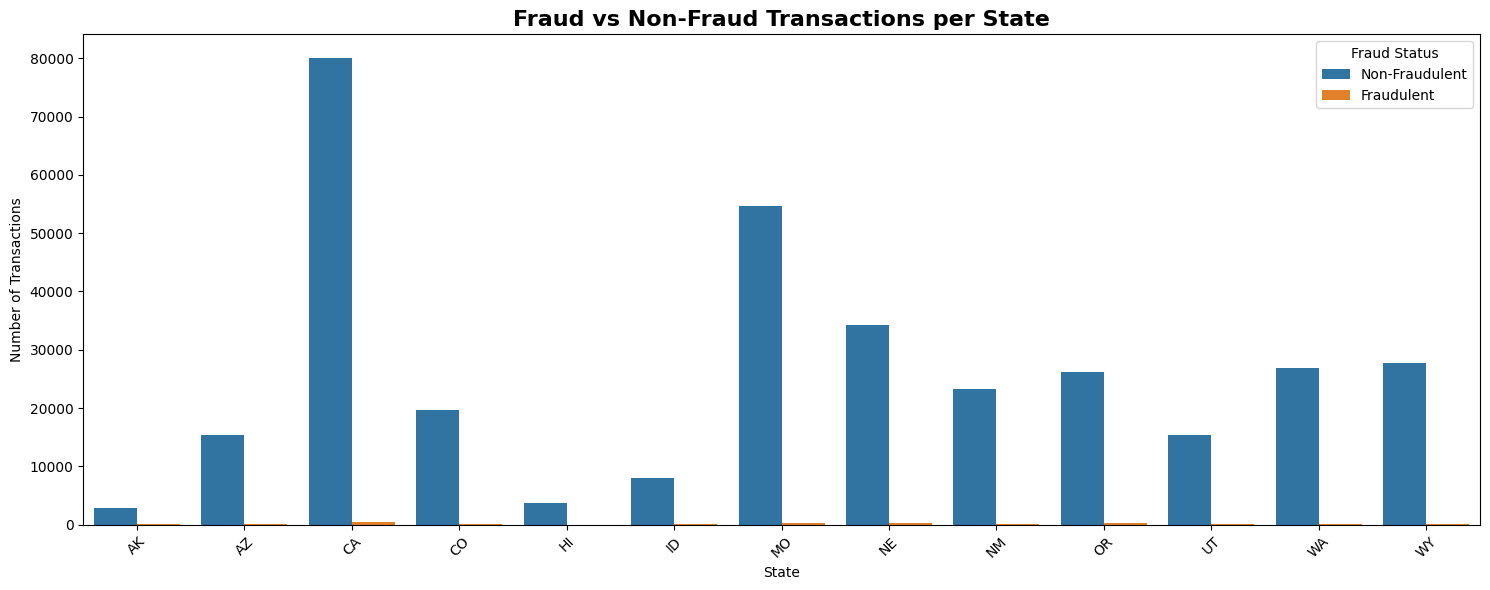

In [ ]:
fraud_distribution = df.groupby(['state', 'is_fraud']).size().reset_index(name='Transaction Count')

# Step 2: Replace fraud flag with labels
fraud_distribution['Fraud Status'] = fraud_distribution['is_fraud'].replace({0: 'Non-Fraudulent', 1: 'Fraudulent'})
fraud_distribution = df.groupby(['state', 'is_fraud']).size().reset_index(name='Transaction Count')

# Replace is_fraud values with readable labels
fraud_distribution['Fraud Status'] = fraud_distribution['is_fraud'].replace({0: 'Non-Fraudulent', 1: 'Fraudulent'})

# Display the result
print(fraud_distribution[['state', 'Fraud Status', 'Transaction Count']])


plt.figure(figsize=(15, 6))
sns.barplot(data=fraud_distribution, x='state',y='Transaction Count',hue='Fraud Status')

plt.title('Fraud vs Non-Fraud Transactions per State', fontsize=16, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



---
### 12.Calculate and list the fraud rate state-wise (hint: fraud rate = state-wise total number of fraud transactions / state-wise total number of transactions) and show the visualization using a bar graph


   state  Total Transactions  Fraud Transactions  Fraud Rate (%)
0     AK                2963                  50            1.69
1     AZ               15362                  64            0.42
2     CA               80495                 402            0.50
3     CO               19766                 115            0.58
4     HI                3649                  16            0.44
5     ID                8035                  33            0.41
6     MO               54904                 262            0.48
7     NE               34425                 216            0.63
8     NM               23427                 121            0.52
9     OR               26408                 197            0.75
10    UT               15357                  61            0.40
11    WA               27040                 126            0.47
12    WY               27776                 119            0.43


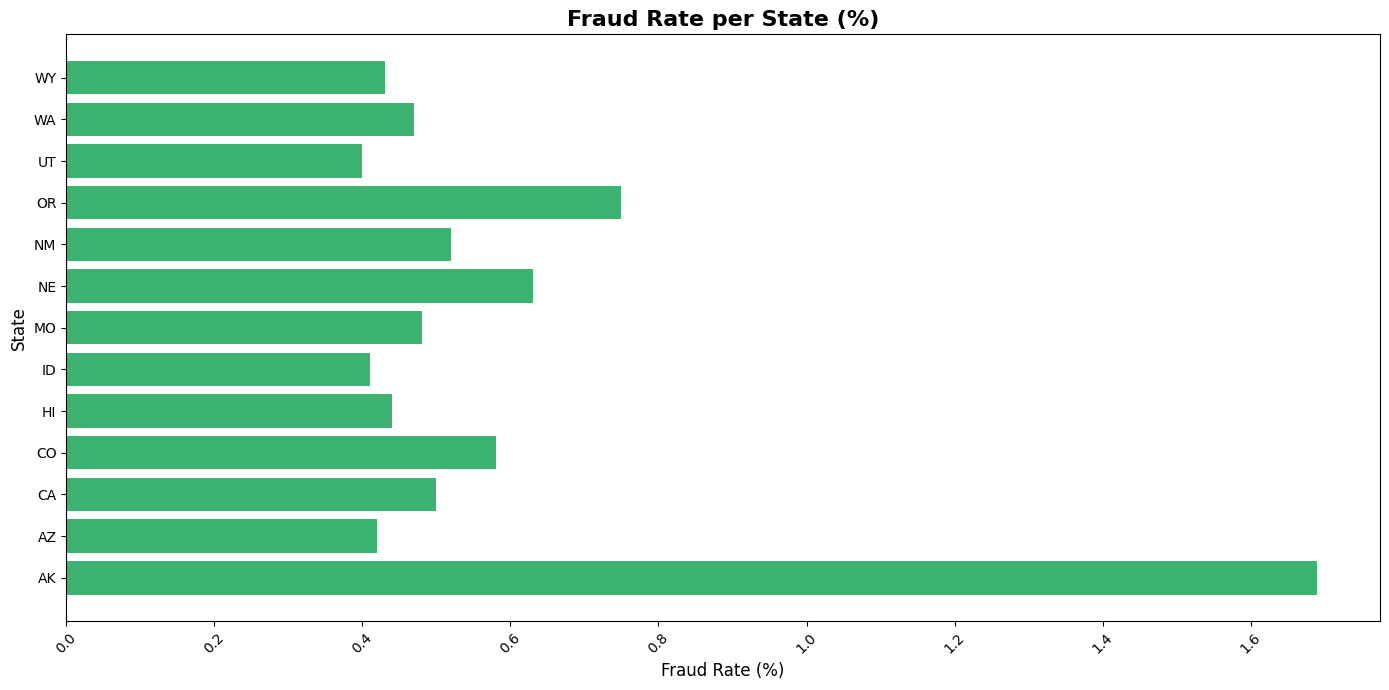

In [ ]:
total_transactions = df.groupby('state').size().reset_index(name='Total Transactions')
fraud_distribution = df.groupby(['state', 'is_fraud']).size().reset_index(name='Transaction Count')

statewise_summary = pd.merge(total_transactions, fraud_transactions, on='state', how='left')

# Calculating fraud rate
statewise_summary['Fraud Rate (%)'] = (statewise_summary['Fraud Transactions'] / statewise_summary['Total Transactions']) * 100
statewise_summary['Fraud Rate (%)'] = statewise_summary['Fraud Rate (%)'].round(2)

#Display the result
print(statewise_summary[['state', 'Total Transactions', 'Fraud Transactions', 'Fraud Rate (%)']])


# Plot
plt.figure(figsize=(14, 7))
plt.barh(statewise_summary['state'], statewise_summary['Fraud Rate (%)'], color='mediumseagreen')

plt.title('Fraud Rate per State (%)', fontsize=16, fontweight='bold')
plt.ylabel('State', fontsize=12)
plt.xlabel('Fraud Rate (%)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()